## Prepare the data

### 1. Load the fine-tuning data

In [1]:
!rm -rf personalize_chatbot
!git clone https://github.com/UruslKhan21/personalize_chatbot.git


Cloning into 'personalize_chatbot'...
remote: Enumerating objects: 246, done.
remote: Counting objects: 100% (246/246), done.
remote: Compressing objects: 100% (164/164), done.
remote: Total 246 (delta 88), reused 235 (delta 77), pack-reused 0 (from 0)
Receiving objects: 100% (246/246), 27.82 MiB | 25.57 MiB/s, done.
Resolving deltas: 100% (88/88), done.


In [2]:
!ls personalize_chatbot


chat.py  data	      minbpe	 README.md	   scripts     transformer
colab	 images       notebooks  requirements.txt  Slides.odp
colab1	 loss_values  output	 RESOURCES.md	   Slides.pdf


In [3]:

!ls /content/personalize_chatbot



chat.py  data	      minbpe	 README.md	   scripts     transformer
colab	 images       notebooks  requirements.txt  Slides.odp
colab1	 loss_values  output	 RESOURCES.md	   Slides.pdf


In [4]:
!ls /content/personalize_chatbot/output


combined_text.txt  fine_tuning	models	pre_training  tokenizer


In [5]:
!ls /content/personalize_chatbot/output/tokenizer


darija_tokenizer.model.model  my_tokenizer.model


In [8]:
import json

with open("/content/personalize_chatbot/output/fine_tuning/data/fine_tuning.json") as f:
    data = json.load(f)


### 2. Load the tokenizer

In [20]:
import sys
sys.path.insert(0, "/content/personalize_chatbot")

In [22]:
from minbpe import RegexTokenizer

tokenizer = RegexTokenizer()
tokenizer.load("/content/personalize_chatbot/output/tokenizer/darija_tokenizer.model.model")




def get_vocab_size(tokenizer: RegexTokenizer) -> int:
    vocab = tokenizer.vocab
    special_tokens = tokenizer.special_tokens

    return len(vocab) + len(special_tokens)

### 3. Tokenize the sequences

In [23]:
tokenized_data = []
for item in data:
    tokenized_item = tokenizer.encode(item, allowed_special="all")
    tokenized_data.append(tokenized_item)

len(tokenized_data[0])

103

### 4. Split the data

We need to be careful when splitting the data. We want to keep the multi-turn conversations complete in each part. So, the training and validation sets should start with a `You` message and end with an `Assistant` message.

In [25]:
initial_split_index = int(0.95 * len(data))

# Adjusting the index to ensure that the training set ends with "Assistant" message
# and that the validation set starts with "You" message

# Scanning backward to find an Assistant message
# ---- CONFIG ----
SEPARATOR = "<|separator|>"
START_ASSISTANT = "<|startoftext|>Assistant"
START_USER = "<|startoftext|>You"

# ---- HELPERS ----
def safe_preview(line: str, sep: str = SEPARATOR, maxlen: int = 120) -> str:
    if not isinstance(line, str):
        return "[NON-STRING LINE]"
    if sep in line:
        return line.split(sep, 1)[0][:maxlen]
    return f"[NO '{sep}' FOUND] {line[:maxlen]}"

def print_previews(name: str, lines: list):
    print(f"\n{name} set:")
    if not lines:
        print("  (empty)")
        return
    print(f"  Count: {len(lines)}")
    print(f"  Start message: {safe_preview(lines[0])}")
    print(f"  End message:   {safe_preview(lines[-1])}")

# ---- CLEAN INPUT ----
# Ensure 'data' is a list of non-empty strings
data = [str(d).strip() for d in data if str(d).strip()]
n = len(data)

if n == 0:
    raise ValueError("Your dataset 'data' is empty after cleaning.")

# ---- FIND SPLIT ----
initial_split_index = max(1, min(int(0.95 * n), n - 1))

# Try to end train on an Assistant message by scanning backward
split_index = initial_split_index
while split_index > 0 and not data[split_index - 1].startswith(START_ASSISTANT):
    split_index -= 1

# If we never found an Assistant boundary, fall back to the 95% split
if split_index == 0:
    split_index = initial_split_index

# Final safety: ensure both sides non-empty
if split_index <= 0:
    split_index = 1
if split_index >= n:
    split_index = n - 1

train_data = data[:split_index]
val_data = data[split_index:]

# ---- OPTIONAL: ensure val starts with a User message; if not, nudge forward
if val_data and not val_data[0].startswith(START_USER):
    # scan forward within a small window to find a You line
    found = False
    for i in range(min(50, len(val_data))):
        if val_data[i].startswith(START_USER):
            train_data = data[:split_index + i]
            val_data = data[split_index + i:]
            found = True
            break
    # if not found, we proceed as-is (no crash)

# ---- PRINT DEBUG + PREVIEWS ----
print(f"Total lines: {n}")
print(f"Split index: {split_index} (train={len(train_data)}, val={len(val_data)})")

print_previews("Training", train_data)
print_previews("Validation", val_data)


Total lines: 51
Split index: 48 (train=48, val=3)

Training set:
  Count: 48
  Start message: <|startoftext|>Person 1
  End message:   <|startoftext|>Person 2

Validation set:
  Count: 3
  Start message: <|startoftext|>Person 1
  End message:   <|startoftext|>Person 1


We got the index that we should use to split the data. Now, let's split the tokenized data.

In [26]:
train_data = tokenized_data[:split_index]
val_data = tokenized_data[split_index:]

Now, we need to combine the `You` and `Assistant` turns into one sequence. We will make sure that the resulting sequence does not exceed the `block_size`.

In [27]:
block_size = 256


def combine_turns(data: list[list[int]], should_trim_long_sequences: bool) -> list[list[int]]:
    combined_turns_data = []
    for i in range(0, len(data)-1, 2):
        you_message = data[i]
        assistant_message = data[i+1]
        if not you_message or not assistant_message:
            continue

        final_message = you_message + assistant_message
        if len(final_message) > block_size and should_trim_long_sequences:
            final_message = final_message[-block_size:]

        combined_turns_data.append(final_message)
    return combined_turns_data


combined_train_data = combine_turns(
    data=train_data,
    should_trim_long_sequences=True
)
combined_val_data = combine_turns(
    data=val_data,
    should_trim_long_sequences=True
)

In [28]:
print("Train data")
print(f"Length before: {len(train_data)}")
print(f"Length after: {len(combined_train_data)}")

print("\nValidation data")
print(f"Length before: {len(val_data)}")
print(f"Length after: {len(combined_val_data)}")

Train data
Length before: 48
Length after: 24

Validation data
Length before: 3
Length after: 1


We will merge the `You` and `Assistant` parts into one sequence. Then, we will try to combine multiple sequences of `You` and `Assistant` into a single input, but only if the sequence length stays smaller than the block size.

In [29]:
def merge_conversation_turns(combined_data: list[list[int]], block_size: int) -> list[list[int]]:
    new_data = []
    current_sequence = []

    for sequence in combined_data:
        if len(current_sequence) + len(sequence) <= block_size:
            current_sequence.extend(sequence)
        else:
            if current_sequence:
                new_data.append(current_sequence)
            current_sequence = sequence.copy()

    # Add the last block if it's not empty
    if current_sequence:
        new_data.append(current_sequence)

    return new_data


merged_train_data = merge_conversation_turns(
    combined_data=combined_train_data,
    block_size=block_size
)
merged_val_data = merge_conversation_turns(
    combined_data=combined_val_data,
    block_size=block_size
)

In [30]:
len(combined_train_data), len(merged_train_data)

(24, 12)

Let's convert each sequence of tokens into a tensor.

In [ ]:
import torch

train_data = torch.tensor(combined_train_data)
val_data = torch.tensor(combined_val_data)

Since our token sequences don't all have the same length, we can't turn the data into a tensor all at once. To do that, all sequences need to have the same length.

That's why we need to use padding to fix this problem. We can add padding at the start or end of the sequence. Let's add it to the start.

In [33]:
import torch
torch.manual_seed(3647)

# The token `<|padding|>` is used to mask the padding tokens.
# Masking means the model will ignore these tokens during training.
# In other words, the loss will not be calculated for these tokens.
#padding_token = tokenizer.special_tokens["<|padding|>"]
padding_token = -100

def apply_padding_to_data(data: list[list[int]], block_size: int, padding_token: int) -> torch.Tensor:
    tensors = []
    for i in range(len(data)):
        tensor = torch.tensor(data[i])
        padded_tensor = torch.nn.functional.pad(
            input=tensor,
            # for right padding:
            pad=(0, block_size - len(tensor)),
            # pad=(block_size - len(tensor), 0),
            value=padding_token
        )
        tensors.append(padded_tensor)

    return torch.stack(tensors)


train_data_tensor = apply_padding_to_data(
    data=merged_train_data,
    block_size=block_size,
    padding_token=padding_token
)
val_data_tensor = apply_padding_to_data(
    data=merged_val_data,
    block_size=block_size,
    padding_token=padding_token
)

train_data_tensor.shape, val_data_tensor.shape

(torch.Size([12, 256]), torch.Size([1, 256]))

In [34]:
train_data_tensor[0]

tensor([  60,  124,  516,  659,  111,  102, 4717,  124,   62,   80,  706,  284,
          32,   49,   60,  124,  747, 2656, 2324,  124,   62,   72,  101,  121,
          10, 3061,  605,  487,  637,   91, 2616,   47, 4049,   47, 1779,   53,
          44,   32,   57,   58, 1446, 3140,   93,   32,  126,  397,  706,  284,
          32,   50,   58,  306,  101,  121,   33,  438, 2784, 3584,   44, 2086,
        2519,  487,  637,   91, 2616,   47, 4049,   47, 1779,   53,   44,   32,
          57,   58,  837, 3140,   93,   32,  126,  397,  706,  284,   32,   49,
          58,  438, 2784, 3584, 3585,   44, 3117,  265, 3118,  264, 1720,   60,
         124,  675,  111,  102, 4717,  124,   62,   60,  124,  516,  659,  111,
         102, 4717,  124,   62,   80,  706,  284,   32,   50,   60,  124,  747,
        2656, 2324,  124,   62,   76, 1721, 4310,  637,   91, 2616,   47, 4049,
          47, 1779,   53,   44,   32,   57,   58, 1887, 3140,   93,   32,  126,
         397,  706,  284,   32,   49,   

In [35]:
val_data_tensor[0]

tensor([  60,  124,  516,  659,  111,  102, 4717,  124,   62,   80,  706,  284,
          32,   49,   60,  124,  747, 2656, 2324,  124,   62,   89,  329,  277,
         686,   63,  438, 1375, 3130, 1561,  487, 4317,  264, 1720,   60,  124,
         675,  111,  102, 4717,  124,   62,   60,  124,  516,  659,  111,  102,
        4717,  124,   62,   80,  706,  284,   32,   50,   60,  124,  747, 2656,
        2324,  124,   62,   78, 1250,   44,  438, 3586, 1327,   60,  124,  675,
         111,  102, 4717,  124,   62, -100, -100, -100, -100, -100, -100, -100,
        -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
        -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
        -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
        -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
        -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
        -100, -100, -100, -100, -100, -1

### 5. Creat the data loaders

In [36]:
from typing import Tuple
from torch.utils.data import Dataset, DataLoader


class FineTuningDataset(Dataset):
    def __init__(self, data: torch.Tensor, device: torch.device, padding_token: int):
        self.data = data  # shape: (num_samples, block_size)
        self.device = device
        self.padding_token = padding_token

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        sample = self.data[index]
        x = sample.to(self.device)
        y = sample[1:].to(self.device)
        padding_tensor = torch.tensor([self.padding_token], device=self.device)
        y = torch.cat((y, padding_tensor))
        return x, y


batch_size = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_dataset = FineTuningDataset(
    data=train_data_tensor,
    device=device,
    padding_token=padding_token
)
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_dataset = FineTuningDataset(
    data=val_data_tensor,
    device=device,
    padding_token=padding_token
)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [37]:
x, y = next(iter(train_loader))
x.shape, y.shape

(torch.Size([12, 256]), torch.Size([12, 256]))

## Fine-tuning

### 1. Load the saved checkpoint

In [39]:
from transformer.model import GPTLanguageModel

block_size = 256
n_embd = 512
n_head = 8
n_layer = 4
dropout = 0.2
batch_size = 64
vocab_size = get_vocab_size(tokenizer)

model = GPTLanguageModel(
    vocab_size=vocab_size,
    block_size=block_size,
    n_embd=n_embd,
    n_head=n_head,
    n_layer=n_layer,
    dropout=dropout,
    device=device,
    #ignore_index=tokenizer.special_tokens["<|padding|>"],
).to(device)
model = torch.compile(model)

print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

17.860488 M parameters


In [9]:
checkpoint_path = "../output/pre_training/run_4/checkpoint_0.pth"
checkpoint = torch.load(checkpoint_path, weights_only=True)
model_state_dict = checkpoint["model_state_dict"]
model.load_state_dict(model_state_dict)

NameError: name 'torch' is not defined

Generate from the model to make sure that the weights were loaded correctly.

In [42]:
input_tokens = tokenizer.encode("Salam labas ", allowed_special="all")
input_tokens = torch.tensor(
    input_tokens, dtype=torch.long).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model.generate(input_tokens=input_tokens, max_new_tokens=100)

print(tokenizer.decode(output[0].tolist()))

Salam labas  disad�oa अद puri Pl thay matricesung144 मबर if________ bhejan Pro am Kya gyepace	C state 😊 uncight Yrr tranning chand mac pakesentationani baarile f m issuesinpleseart everytुलस meneat Students katava हसनतहura� min Comb project Onlineject fr gate Apniिलjj Vidya problemses�quidSeआपgth Mixture hisab genat com36csv Randion Huiआप25 yaaramart Dakha rpec acे

 speed dak barish',
 gayi R ThiTransPublic murshidCP labeled


### 2. Estimate loss

In [43]:
from typing import Dict


@torch.no_grad()
def estimate_loss(
    model: torch.nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
) -> Dict[str, float]:
    output = {}
    model.eval()

    for split, loader in [('train', train_loader), ('val', val_loader)]:
        losses = []
        for x, y in loader:
            with torch.no_grad():
                _, loss = model(x, y)
            losses.append(loss.item())
        output[split] = sum(losses) / len(losses)

    model.train()
    return output

### 3. Save checkpoints

In [44]:
def save_checkpoint(
    model: GPTLanguageModel,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    loss: float,
    file_path: str = "checkpoint.pth"
) -> None:
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss
    }
    torch.save(checkpoint, file_path)

### 4. Training loop

In [55]:
import os
max_iters = 100
eval_interval = 4
learning_rate = 15e-4

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
train_losses = []
val_losses = []

for iteration in range(max_iters):
    for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
        # Evaluation
        if batch_idx % eval_interval == 0 or batch_idx == len(train_loader) - 1:
            losses = estimate_loss(
                model=model,
                train_loader=train_loader,
                val_loader=val_loader,
            )
            train_losses.append(losses['train'])
            val_losses.append(losses['val'])

            print(
                f"iteration {iteration} / step {batch_idx}: "
                f"train loss {losses['train']:.4f}, "
                f"val loss {losses['val']:.4f}"
            )

        # Training step
        logits, loss = model(x_batch, y_batch)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

    # Save checkpoint
  
# Create directory in Colab
save_dir = "/content/personalize_chatbot/output/fine_tuning"
os.makedirs(save_dir, exist_ok=True)

save_checkpoint(
    model=model,
    optimizer=optimizer,
    epoch=iteration,
    loss=loss.item(),
    file_path=f"{save_dir}/checkpoint_{iteration}.pth"
)


iteration 0 / step 0: train loss 0.0147, val loss 2.0082
iteration 1 / step 0: train loss 5.6481, val loss 5.4678
iteration 2 / step 0: train loss 6.8453, val loss 6.8582
iteration 3 / step 0: train loss 4.5925, val loss 4.6272
iteration 4 / step 0: train loss 4.2980, val loss 4.3749
iteration 5 / step 0: train loss 3.8321, val loss 3.9016
iteration 6 / step 0: train loss 3.2064, val loss 3.2461
iteration 7 / step 0: train loss 2.5387, val loss 2.5794
iteration 8 / step 0: train loss 2.3812, val loss 2.4440
iteration 9 / step 0: train loss 2.2695, val loss 2.3372
iteration 10 / step 0: train loss 2.2441, val loss 2.1055
iteration 11 / step 0: train loss 2.0851, val loss 2.1080
iteration 12 / step 0: train loss 2.1094, val loss 2.2557
iteration 13 / step 0: train loss 1.9595, val loss 2.1550
iteration 14 / step 0: train loss 1.8246, val loss 2.0793
iteration 15 / step 0: train loss 1.7040, val loss 2.0105
iteration 16 / step 0: train loss 1.5520, val loss 1.9776
iteration 17 / step 0: t

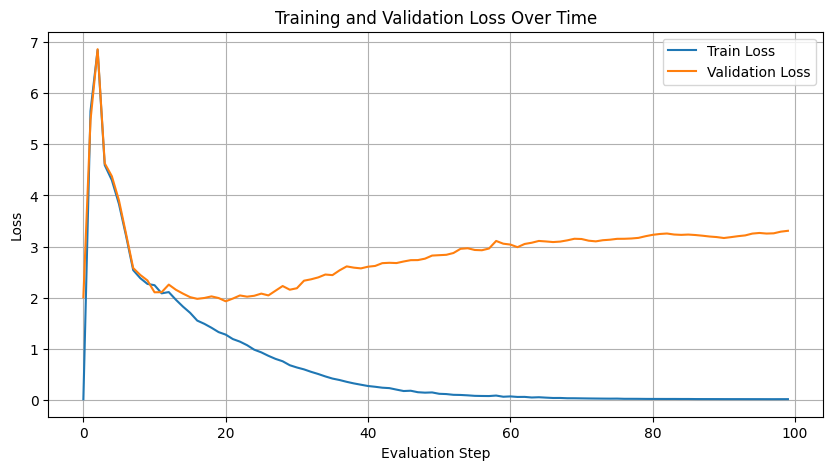

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Time")
plt.legend()
plt.grid()
plt.show()

In [57]:
def get_input_tokens(message: str) -> torch.Tensor:
    input_tokens = tokenizer.encode(
        f"<|startoftext|>{message}<|separator|>", allowed_special="all")
    input_tokens = torch.tensor(
        input_tokens, dtype=torch.long).unsqueeze(0).to(device)
    return input_tokens


user_message = "Salam "
input_tokens = get_input_tokens(message=user_message)
model_answer = ""

model.eval()
while True:
    output_tokens = model.generate(input_tokens=input_tokens, max_new_tokens=1)
    last_generated_token = output_tokens[0, -1].item()
    #if last_generated_token == tokenizer.special_tokens["<|endoftext|>"]:
        #break

    input_tokens = torch.cat((input_tokens, output_tokens[:, -1:]), dim=1)
    model_answer += tokenizer.decode([last_generated_token])

    if len(output_tokens[0]) > block_size:
        break

print(f"You: {user_message}")
print(f"Assistant: {model_answer}")

You: Salam 
Assistant: SereHahaha classic, which show?<|endoftext|><|startoftext|>Person 2<|separator|>Breaking Bad, ever watched it?
[26/02/2025, 9:30 AM] ~ Person 1: Oh yeah, one of my favorites!<|endoftext|>It are youwor- did will, 9: rlso, I s l get r’t wait � ends:gPerson ~ Person 1: Yeah, had to finish some work<|endoftext|>Bh2<|separator|>Yeah, let?
[26/02/2025, whatuck part<|>Person 1:20 then finator|>5 PM?
[26/02/2025, 9:39 AM] ~ Person 1: Or do you prefer later?
5 PM works for me<|endoftext|>I
